100%|██████████| 581/581 [03:41<00:00,  2.63it/s]



--- Starting Fold 1 ---
Fold 1 | Epoch  10 | Spec AUC: 0.7952 (Acc: 60.53%) | Spat AUC: 0.7111 (Acc: 68.42%)
Fold 1 | Epoch  20 | Spec AUC: 0.8393 (Acc: 74.56%) | Spat AUC: 0.7243 (Acc: 64.04%)
Fold 1 | Epoch  30 | Spec AUC: 0.8783 (Acc: 77.19%) | Spat AUC: 0.7333 (Acc: 62.28%)
Fold 1 | Epoch  40 | Spec AUC: 0.8844 (Acc: 77.19%) | Spat AUC: 0.6853 (Acc: 62.28%)
Fold 1 | Epoch  50 | Spec AUC: 0.8834 (Acc: 80.70%) | Spat AUC: 0.6844 (Acc: 62.28%)
Fold 1 | Epoch  60 | Spec AUC: 0.8879 (Acc: 77.19%) | Spat AUC: 0.6799 (Acc: 62.28%)
Fold 1 | Epoch  70 | Spec AUC: 0.8899 (Acc: 80.70%) | Spat AUC: 0.6731 (Acc: 60.53%)
Fold 1 | Epoch  80 | Spec AUC: 0.8973 (Acc: 80.70%) | Spat AUC: 0.6707 (Acc: 61.40%)
Fold 1 | Epoch  90 | Spec AUC: 0.8808 (Acc: 81.58%) | Spat AUC: 0.6702 (Acc: 60.53%)
Fold 1 | Epoch 100 | Spec AUC: 0.8783 (Acc: 80.70%) | Spat AUC: 0.6765 (Acc: 60.53%)
Fold 1 | Epoch 110 | Spec AUC: 0.9008 (Acc: 80.70%) | Spat AUC: 0.6755 (Acc: 60.53%)
Fold 1 | Epoch 120 | Spec AUC: 0.8828 (A

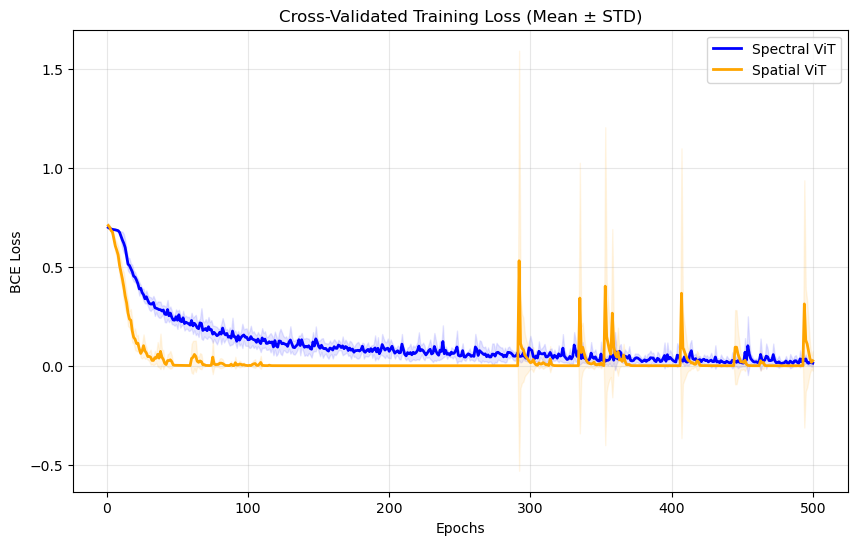

In [1]:
import os
import re
import nibabel as nib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, accuracy_score
from scipy.stats import norm
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
from util import seed_everything

seed_everything(0)

# Statistical helper functions
def delong_roc_test(ground_truth, predictions_one, predictions_two):
    """
    Statistically compares two AUCs. Returns (auc1, auc2, p_value).
    """
    auc1 = roc_auc_score(ground_truth, predictions_one)
    auc2 = roc_auc_score(ground_truth, predictions_two)
    pos_mask, neg_mask = (ground_truth == 1), (ground_truth == 0)
    m, n = np.sum(pos_mask), np.sum(neg_mask)
    def get_components(preds):
        pos_preds, neg_preds = preds[pos_mask], preds[neg_mask]
        v10 = np.array([(np.sum(neg_preds < p) + 0.5 * np.sum(neg_preds == p)) / n for p in pos_preds])
        v01 = np.array([(np.sum(pos_preds > p) + 0.5 * np.sum(pos_preds == p)) / m for p in neg_preds])
        return v10, v01
    v10_1, v01_1 = get_components(predictions_one)
    v10_2, v01_2 = get_components(predictions_two)
    var1 = np.var(v10_1, ddof=1)/m + np.var(v01_1, ddof=1)/n
    var2 = np.var(v10_2, ddof=1)/m + np.var(v01_2, ddof=1)/n
    covariance = np.cov(v10_1, v10_2)[0,1]/m + np.cov(v01_1, v01_2)[0,1]/n
    se = np.sqrt(max(1e-10, var1 + var2 - 2 * covariance))
    z = (auc1 - auc2) / se
    return auc1, auc2, 2 * (1 - norm.cdf(np.abs(z)))

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Models
import torch
import torch.nn as nn

class SpectralViT(nn.Module):
    def __init__(self, n_inputs, n_heads=2, embed_dim=16, n_layers=4):
        super().__init__()
        # Spectral decay coefficients (1/f)
        ranks = torch.arange(1, n_inputs + 1, dtype=torch.float32)
        self.rank_weights = nn.Parameter(1.0 / ranks)
        # N x d_e Expansion: Each of the N inputs gets its own direction vector.
        # This replaces the nn.Linear(1, embed_dim) bottleneck.
        self.mode_weights = nn.Parameter(torch.randn(n_inputs, embed_dim) * 0.02)
        # Positional embeddings to maintain identity of each harmonic mode
        self.pos_embed = nn.Parameter(torch.randn(n_inputs, 1, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=n_heads, 
            dim_feedforward=embed_dim * 2, 
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim), 
            nn.Linear(embed_dim, 1)
        )

    def forward(self, x):
        # x shape: [batch, n_inputs]
        b = x.shape[0]
        # Apply spectral weighting (1/f)
        x = x * self.rank_weights
        # Component-Specific Projection:
        # [batch, n_inputs, 1] * [1, n_inputs, embed_dim] -> [batch, n_inputs, embed_dim]
        # This lifts the sequence into a full-rank subspace.
        x = x.unsqueeze(-1) * self.mode_weights.unsqueeze(0)
        # Prepare for Transformer [seq_len, batch, embed_dim]
        x = x.transpose(0, 1)
        x = x + self.pos_embed
        # Contextualize modes via self-attention
        x = self.transformer(x)
        # Global Average Pooling across the spectral sequence
        x = x.mean(dim=0)
        # Classification head
        return self.mlp_head(x).squeeze(-1)

class SpatialViT(nn.Module):
    def __init__(self, vol_size=96, patch_size=12, embed_dim=128, n_heads=4, n_layers=2):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches = (vol_size // patch_size) ** 3
        self.proj = nn.Linear(patch_size ** 3, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(self.n_patches + 1, 1, embed_dim) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=n_heads, dim_feedforward=embed_dim*2, dropout=0.2)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.mlp_head = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, 1))

    def forward(self, x):
        b = x.shape[0]
        p = self.patch_size
        x = x.unfold(2, p, p).unfold(3, p, p).unfold(4, p, p).contiguous().view(b, self.n_patches, -1)
        x = self.proj(x).transpose(0, 1)
        cls_tokens = self.cls_token.expand(1, b, -1)
        x = torch.cat((cls_tokens, x), dim=0)
        x = x + self.pos_embed
        x = self.transformer(x)
        return self.mlp_head(x[0]).squeeze(-1)

# Load data
def load_ixi_3d(data_dir, csv_path, crop_size=96):
    df = pd.read_csv(csv_path)
    id_col = [c for c in df.columns if 'ID' in c.upper()][0]
    sex_col = [c for c in df.columns if 'SEX' in c.upper()][0]
    df[id_col] = df[id_col].astype(int)
    sex_lookup = dict(zip(df[id_col], df[sex_col].map({1: 0, 2: 1})))
    files = sorted([f for f in os.listdir(data_dir) if f.endswith('.nii.gz')])
    vols, labels = [], []
    for f in tqdm(files):
        match = re.search(r'(\d+)', f)
        if match and int(match.group(1)) in sex_lookup:
            subj_id = int(match.group(1))
            img = nib.load(os.path.join(data_dir, f)).get_fdata()
            pad_widths = [(max(0, (crop_size - s)//2), max(0, (crop_size - s + 1)//2)) for s in img.shape]
            img = np.pad(img, pad_widths, mode='constant')
            c = np.array(img.shape) // 2
            r = crop_size // 2
            crop = img[c[0]-r:c[0]+r, c[1]-r:c[1]+r, c[2]-r:c[2]+r]
            if crop.shape == (crop_size, crop_size, crop_size):
                crop = (crop - np.mean(crop)) / (np.std(crop) + 1e-8)
                vols.append(crop.astype(np.float32)); labels.append(sex_lookup[subj_id])
    return np.array(vols), np.array(labels).astype(np.float32)

# Training loop
MNI_DIR, CSV_PATH = './data/IXI_extracted/', './data/IXI_extracted/IXI.csv'
VOL_SIZE, N_COMP, EPOCHS, BATCH_SIZE = 96, 128, 500, 4
device = torch.device("cuda:6" if torch.cuda.is_available() else "cpu")

X, Y = load_ixi_3d(MNI_DIR, CSV_PATH, crop_size=VOL_SIZE)
X_flat = X.reshape(len(X), -1)

# Parameter counts
m_spec_tmp = SpectralViT(n_inputs=N_COMP, embed_dim=16)
m_spat_tmp = SpatialViT(vol_size=VOL_SIZE)
params_spec = count_parameters(m_spec_tmp)
params_spat = count_parameters(m_spat_tmp)

oof_y_true = []
oof_probs_spec = []
oof_probs_spat = []

kf = KFold(n_splits=5, shuffle=True, random_state=0)
# --- ADD THIS BEFORE THE K-FOLD LOOP ---
all_folds_history = {
    'spec_loss': [], 
    'spat_loss': []
}
for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    pca = PCA(n_components=N_COMP, whiten=True).fit(X_flat[train_idx])
    tr_pca = torch.from_numpy(pca.transform(X_flat[train_idx])).float()
    tr_vol = torch.from_numpy(X[train_idx]).unsqueeze(1).float()
    tr_y = torch.from_numpy(Y[train_idx]).float()
    
    ts_pca = torch.from_numpy(pca.transform(X_flat[test_idx])).float().to(device)
    ts_vol = torch.from_numpy(X[test_idx]).unsqueeze(1).float().to(device)
    ts_y = torch.from_numpy(Y[test_idx]).float().to(device)

    train_loader = DataLoader(TensorDataset(tr_pca, tr_vol, tr_y), batch_size=BATCH_SIZE, shuffle=True)
    m_spec = SpectralViT(n_inputs=N_COMP, embed_dim=16).to(device)
    m_spat = SpatialViT(vol_size=VOL_SIZE).to(device)
    opt_spec = optim.AdamW(m_spec.parameters(), lr=1e-4); opt_spat = optim.AdamW(m_spat.parameters(), lr=1e-4)
    criterion = nn.BCEWithLogitsLoss()

    print(f"\n--- Starting Fold {fold+1} ---")
    fold_spec_losses = [] 
    fold_spat_losses = []
    for epoch in range(1, EPOCHS + 1):
        m_spec.train(); m_spat.train()
        epoch_spec_loss = 0; epoch_spat_loss = 0
        for b_pca, b_vol, b_y in train_loader:
            b_pca, b_vol, b_y = b_pca.to(device), b_vol.to(device), b_y.to(device)
            opt_spec.zero_grad(); l_spec = criterion(m_spec(b_pca), b_y); l_spec.backward(); opt_spec.step(); epoch_spec_loss += l_spec.item()
            opt_spat.zero_grad(); l_spat = criterion(m_spat(b_vol), b_y); l_spat.backward(); opt_spat.step(); epoch_spat_loss += l_spat.item()

        fold_spec_losses.append(epoch_spec_loss / len(train_loader))
        fold_spat_losses.append(epoch_spat_loss / len(train_loader))
        if epoch % 10 == 0:
                    with torch.no_grad():
                        m_spec.eval(); m_spat.eval()
                        
                        # Get probabilities for AUC
                        prob_spec = torch.sigmoid(m_spec(ts_pca))
                        prob_spat = torch.sigmoid(m_spat(ts_vol))
                        
                        # Calculate AUC
                        auc_spec = roc_auc_score(ts_y.cpu().numpy(), prob_spec.cpu().numpy())
                        auc_spat = roc_auc_score(ts_y.cpu().numpy(), prob_spat.cpu().numpy())
                        
                        # Calculate accuracy
                        acc_spec = ((prob_spec > 0.5).float() == ts_y).float().mean()
                        acc_spat = ((prob_spat > 0.5).float() == ts_y).float().mean()
                        
                        print(f"Fold {fold+1} | Epoch {epoch:3d} | "
                            f"Spec AUC: {auc_spec:.4f} (Acc: {acc_spec:.2%}) | "
                            f"Spat AUC: {auc_spat:.4f} (Acc: {acc_spat:.2%})")
    all_folds_history['spec_loss'].append(fold_spec_losses)
    all_folds_history['spat_loss'].append(fold_spat_losses)
    # Collect final fold predictions
    with torch.no_grad():
        m_spec.eval(); m_spat.eval()
        oof_y_true.append(ts_y.cpu().numpy())
        oof_probs_spec.append(torch.sigmoid(m_spec(ts_pca)).cpu().numpy())
        oof_probs_spat.append(torch.sigmoid(m_spat(ts_vol)).cpu().numpy())

# Summary

y_final = np.concatenate(oof_y_true)
p_spec_final = np.concatenate(oof_probs_spec)
p_spat_final = np.concatenate(oof_probs_spat)

auc_spec, auc_spat, p_val = delong_roc_test(y_final, p_spec_final, p_spat_final)
acc_spec = accuracy_score(y_final, p_spec_final > 0.5)
acc_spat = accuracy_score(y_final, p_spat_final > 0.5)

print("\n" + "="*50)
print("FINAL CROSS-VALIDATION RESULTS")
print("="*50)
print(f"Spectral ViT Mean AUC: {auc_spec:.4f}")
print(f"Spatial ViT  Mean AUC: {auc_spat:.4f}")
print(f"DeLong Test P-Value:   {p_val:.4f}")
print("-" * 50)
print(f"Spectral ViT Accuracy: {acc_spec:.2%}")
print(f"Spatial ViT  Accuracy: {acc_spat:.2%}")
print("="*50)

import matplotlib.pyplot as plt

def plot_cv_losses(history_dict):
    plt.figure(figsize=(10, 6))
    epochs = range(1, len(history_dict['spec_loss'][0]) + 1)
    
    for key, label, color in [('spec_loss', 'Spectral ViT', 'blue'), 
                              ('spat_loss', 'Spatial ViT', 'orange')]:
        data = np.array(history_dict[key]) # Shape: (Folds, Epochs)
        mean_loss = np.mean(data, axis=0)
        std_loss = np.std(data, axis=0)
        
        plt.plot(epochs, mean_loss, label=label, color=color, lw=2)
        plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.1)

    plt.title("Cross-Validated Training Loss (Mean ± STD)")
    plt.xlabel("Epochs")
    plt.ylabel("BCE Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_cv_losses(all_folds_history)

In [2]:
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
from statsmodels.stats.contingency_tables import mcnemar

# Aggregate predictions
y_final = np.concatenate(oof_y_true)
p_spec_final = np.concatenate(oof_probs_spec)
p_spat_final = np.concatenate(oof_probs_spat)
preds_spec = (p_spec_final > 0.5).astype(int)
preds_spat = (p_spat_final > 0.5).astype(int)

# AUC significance (DeLong)
_, _, p_auc = delong_roc_test(y_final, p_spec_final, p_spat_final)

# Accuracy significance (McNemar)
both_correct = np.sum((preds_spec == y_final) & (preds_spat == y_final))
spec_correct_spat_wrong = np.sum((preds_spec == y_final) & (preds_spat != y_final))
spat_correct_spec_wrong = np.sum((preds_spat == y_final) & (preds_spec != y_final))
both_wrong = np.sum((preds_spec != y_final) & (preds_spat != y_final))

table = [[both_correct, spec_correct_spat_wrong],
         [spat_correct_spec_wrong, both_wrong]]

p_acc = mcnemar(table, exact=True).pvalue

# Results
print("\n" + "="*95)
print(f"{'Metric':<25} | {'Spectral ViT':<15} | {'Spatial ViT':<15} | {'P-Value'}")
print("-" * 95)
print(f"{'Mean AUC':<25} | {roc_auc_score(y_final, p_spec_final):<15.4f} | {roc_auc_score(y_final, p_spat_final):<15.4f} | {p_auc:.4f}")
print(f"{'Mean Accuracy':<25} | {accuracy_score(y_final, preds_spec):<15.2%} | {accuracy_score(y_final, preds_spat):<15.2%} | {p_acc:.4f}")
print(f"{'Parameters':<25} | {params_spec:<15,} | {params_spat:<15,} | --")
print("="*95)


Metric                    | Spectral ViT    | Spatial ViT     | P-Value
-----------------------------------------------------------------------------------------------
Mean AUC                  | 0.8416          | 0.6913          | 0.0000
Mean Accuracy             | 79.51%          | 66.96%          | 0.0000
Parameters                | 13,169          | 552,449         | --


Spectral Params: 13,169
Matched Spatial Params: 28,237
Heavy Spatial Params: 552,449
Training Matched Spatial Fold 1...
Training Matched Spatial Fold 2...
Training Matched Spatial Fold 3...
Training Matched Spatial Fold 4...
Training Matched Spatial Fold 5...

Metric               | Spectral ViT       | Spatial (Heavy)    | Spatial (Matched)  | P-Val (Spec vs Match)
-----------------------------------------------------------------------------------------------------------------------------
Mean AUC             | 0.8416             | 0.6913             | 0.6164             | 0.0000
Mean Accuracy        | 79.51%             | 66.96%             | 59.89%             | 0.0000
Parameters           | 13,169             | 552,449            | 28,237             | --


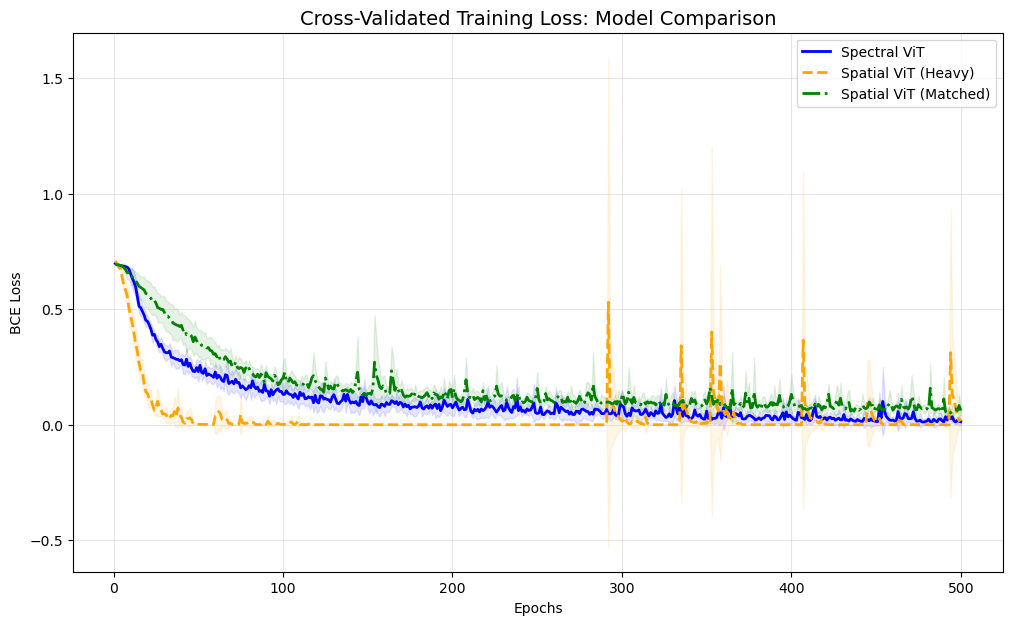

In [3]:
# Matched spatial model
# Adjusting embed_dim and heads to match SpectralViT (~12k parameters)
all_folds_history['spat_match_loss'] = []
m_spat_matched_tmp = SpatialViT(vol_size=VOL_SIZE, patch_size=12, embed_dim=12, n_heads=1, n_layers=1)
params_spat_matched = count_parameters(m_spat_matched_tmp)

oof_probs_spat_matched = []

print(f"Spectral Params: {params_spec:,}")
print(f"Matched Spatial Params: {params_spat_matched:,}")
print(f"Heavy Spatial Params: {params_spat:,}")

# Train with same splits
kf = KFold(n_splits=5, shuffle=True, random_state=0)

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    # Prepare spatial data (X is already 3D)
    tr_vol = torch.from_numpy(X[train_idx]).unsqueeze(1).float()
    tr_y = torch.from_numpy(Y[train_idx]).float()
    ts_vol = torch.from_numpy(X[test_idx]).unsqueeze(1).float().to(device)
    ts_y = torch.from_numpy(Y[test_idx]).float().to(device)

    train_loader = DataLoader(TensorDataset(tr_vol, tr_y), batch_size=BATCH_SIZE, shuffle=True)
    
    # Initialize
    m_match = SpatialViT(vol_size=VOL_SIZE, patch_size=12, embed_dim=12, n_heads=1, n_layers=1).to(device)
    optimizer = optim.AdamW(m_match.parameters(), lr=1e-4)
    criterion = nn.BCEWithLogitsLoss()

    print(f"Training Matched Spatial Fold {fold+1}...")
    fold_match_losses = []
    for epoch in range(1, EPOCHS + 1):
        m_match.train()
        epoch_loss_spatm = 0
        for b_vol, b_y in train_loader:
            b_vol, b_y = b_vol.to(device), b_y.to(device)
            optimizer.zero_grad()
            l_spatm = criterion(m_match(b_vol), b_y); l_spatm.backward()
            optimizer.step()
            epoch_loss_spatm += l_spatm.item()
        
        # Save average epoch loss
        fold_match_losses.append(epoch_loss_spatm / len(train_loader))
    # Store fold history
    all_folds_history['spat_match_loss'].append(fold_match_losses)
    with torch.no_grad():
        m_match.eval()
        oof_probs_spat_matched.append(torch.sigmoid(m_match(ts_vol)).cpu().numpy())

# Results
from sklearn.metrics import accuracy_score
from statsmodels.stats.contingency_tables import mcnemar

p_match_final = np.concatenate(oof_probs_spat_matched)
preds_match = (p_match_final > 0.5).astype(int)

# P-values (spectral, DeLong)
_, _, p_auc_heavy = delong_roc_test(y_final, p_spec_final, p_spat_final)
_, _, p_auc_match = delong_roc_test(y_final, p_spec_final, p_match_final)

# Accuracy (Spectral, McNemar)
table_match = [[np.sum((preds_spec == y_final) & (preds_match == y_final)), np.sum((preds_spec == y_final) & (preds_match != y_final))],
               [np.sum((preds_match == y_final) & (preds_spec != y_final)), np.sum((preds_spec != y_final) & (preds_match != y_final))]]
p_acc_match = mcnemar(table_match, exact=True).pvalue

print("\n" + "="*125)
print(f"{'Metric':<20} | {'Spectral ViT':<18} | {'Spatial (Heavy)':<18} | {'Spatial (Matched)':<18} | {'P-Val (Spec vs Match)'}")
print("-" * 125)
print(f"{'Mean AUC':<20} | {roc_auc_score(y_final, p_spec_final):<18.4f} | {roc_auc_score(y_final, p_spat_final):<18.4f} | {roc_auc_score(y_final, p_match_final):<18.4f} | {p_auc_match:.4f}")
print(f"{'Mean Accuracy':<20} | {accuracy_score(y_final, preds_spec):<18.2%} | {accuracy_score(y_final, preds_spat):<18.2%} | {accuracy_score(y_final, preds_match):<18.2%} | {p_acc_match:.4f}")
print(f"{'Parameters':<20} | {params_spec:<18,} | {params_spat:<18,} | {params_spat_matched:<18,} | --")
print("="*125)

# --- 3. Final Comparison Plotting Cell ---
def plot_all_model_losses(history_dict):
    plt.figure(figsize=(12, 7))
    
    # Mapping keys to labels and styles
    configs = [
        ('spec_loss', 'Spectral ViT', 'blue', '-'),
        ('spat_loss', 'Spatial ViT (Heavy)', 'orange', '--'),
        ('spat_match_loss', 'Spatial ViT (Matched)', 'green', '-.')
    ]
    
    for key, label, color, style in configs:
        if key in history_dict and len(history_dict[key]) > 0:
            data = np.array(history_dict[key])
            mean_loss = np.mean(data, axis=0)
            std_loss = np.std(data, axis=0)
            epochs = range(1, len(mean_loss) + 1)
            
            plt.plot(epochs, mean_loss, label=label, color=color, linestyle=style, lw=2)
            plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.1)

    plt.title("Cross-Validated Training Loss: Model Comparison", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("BCE Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_all_model_losses(all_folds_history)

In [4]:
import pandas as pd
import os

# Data summary
n_total = len(Y)
n_male = int(np.sum(Y == 0))
n_female = int(np.sum(Y == 1))

# Extract sites from filenames
files = sorted([f for f in os.listdir(MNI_DIR) if f.endswith('.nii.gz')])
sites = []
for f in files:
    if 'Guys' in f: sites.append('Guys')
    elif 'HH' in f: sites.append('HH')
    elif 'IOP' in f: sites.append('IOP')
    else: sites.append('Unknown')

site_counts = pd.Series(sites).value_counts()

# Pre-calculate percentages to avoid f-string format errors
p_male = (n_male / n_total) * 100
p_female = (n_female / n_total) * 100

# Print
print("="*40)
print(f"{'IXI DATASET SUMMARY (N=566)':^40}")
print("="*40)
print(f"Total Subjects:   {n_total}")
print(f"Male:             {n_male} ({p_male:.1f}%)")
print(f"Female:           {n_female} ({p_female:.1f}%)")
print("-" * 40)
print("Site Distribution:")
for site, count in site_counts.items():
    s_pct = (count / n_total) * 100
    print(f"  {site:<15} {count} ({s_pct:.1f}%)")
print("="*40)


      IXI DATASET SUMMARY (N=566)       
Total Subjects:   566
Male:             254 (44.9%)
Female:           312 (55.1%)
----------------------------------------
Site Distribution:
  Guys            322 (56.9%)
  HH              185 (32.7%)
  IOP             74 (13.1%)


Training Attention U-Net Fold 1...
Training Attention U-Net Fold 2...
Training Attention U-Net Fold 3...
Training Attention U-Net Fold 4...
Training Attention U-Net Fold 5...

Metric               | Spectral ViT       | Spatial (Heavy)    | Spatial (Matched)  | Attn U-Net        
-----------------------------------------------------------------------------------------------------------------------------
Mean Accuracy        | 79.51%             | 66.96%             | 59.89%             | 73.32%            
Sensitivity          | 84.62%             | 70.19%             | 62.82%             | 84.29%            
Specificity          | 73.23%             | 62.99%             | 56.30%             | 59.84%            
Mean AUC             | 0.8416             | 0.6913             | 0.6164             | 0.8258            
-----------------------------------------------------------------------------------------------------------------------------
Parameters           | 13,169             | 552

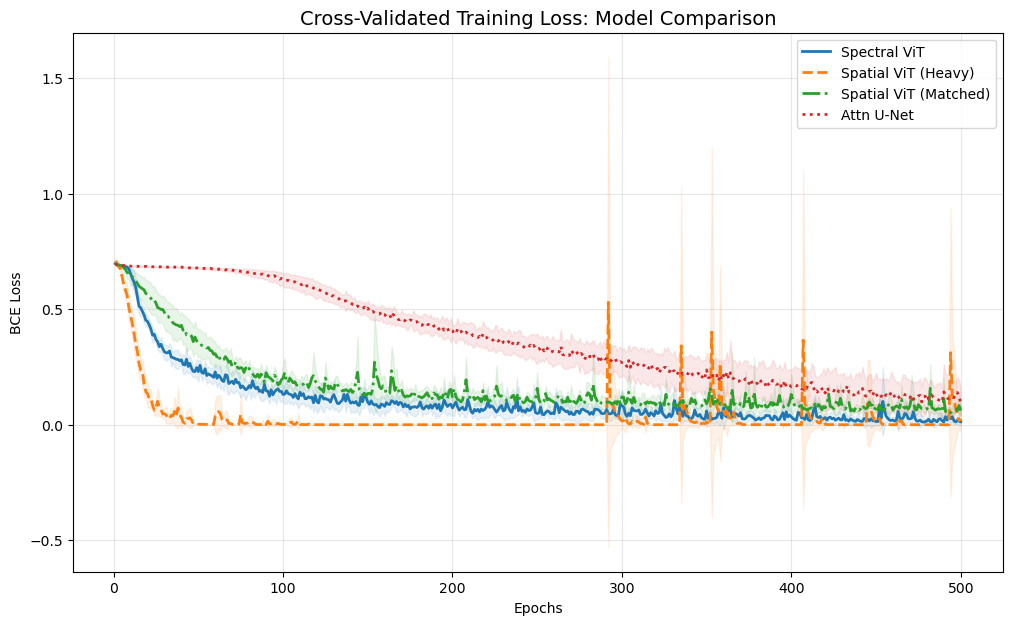

In [5]:
# Attention U-net encoder
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv3d(F_g, F_int, kernel_size=1), nn.BatchNorm3d(F_int))
        self.W_x = nn.Sequential(nn.Conv3d(F_l, F_int, kernel_size=1), nn.BatchNorm3d(F_int))
        self.psi = nn.Sequential(nn.Conv3d(F_int, 1, kernel_size=1), nn.BatchNorm3d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class CompactAttnUNet(nn.Module):
    def __init__(self, in_channels=1, base_filters=7):
        super().__init__()
        # Encoder
        self.conv1 = nn.Conv3d(in_channels, base_filters, 3, padding=1, stride=2) # 48
        self.conv2 = nn.Conv3d(base_filters, base_filters*2, 3, padding=1, stride=2) # 24
        self.conv3 = nn.Conv3d(base_filters*2, base_filters*4, 3, padding=1, stride=2) # 12
        
        # Attention
        self.attn = AttentionBlock(F_g=base_filters*4, F_l=base_filters*4, F_int=base_filters*2)
        
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.classifier = nn.Linear(base_filters*4, 1)

    def forward(self, x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        x3 = F.relu(self.conv3(x2))
        
        # Self-attention on latent space
        g = self.attn(g=x3, x=x3)
        
        out = self.pool(g).view(g.size(0), -1)
        return self.classifier(out).squeeze(-1)

# Train
oof_probs_unet = []
m_unet_tmp = CompactAttnUNet()
params_unet = count_parameters(m_unet_tmp)
unet_history = {'unet_loss': []}
kf = KFold(n_splits=5, shuffle=True, random_state=0)

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    tr_vol = torch.from_numpy(X[train_idx]).unsqueeze(1).float()
    tr_y = torch.from_numpy(Y[train_idx]).float()
    ts_vol = torch.from_numpy(X[test_idx]).unsqueeze(1).float().to(device)
    ts_y = torch.from_numpy(Y[test_idx]).float().to(device)

    train_loader = DataLoader(TensorDataset(tr_vol, tr_y), batch_size=BATCH_SIZE, shuffle=True)
    m_unet = CompactAttnUNet().to(device)
    optimizer = optim.AdamW(m_unet.parameters(), lr=1e-4)
    criterion = nn.BCEWithLogitsLoss()

    print(f"Training Attention U-Net Fold {fold+1}...")
    fold_unet_losses = []
    for epoch in range(1, EPOCHS + 1):
        m_unet.train()
        epoch_loss_unet = 0
        for b_vol, b_y in train_loader:
            b_vol, b_y = b_vol.to(device), b_y.to(device)
            optimizer.zero_grad()
            l_unet = criterion(m_unet(b_vol), b_y); l_unet.backward()
            optimizer.step()
            epoch_loss_unet += l_unet.item()
        
        # Save average epoch loss
        fold_unet_losses.append(epoch_loss_unet / len(train_loader))
    # Store fold history
    unet_history['unet_loss'].append(fold_unet_losses)

    with torch.no_grad():
        m_unet.eval()
        oof_probs_unet.append(torch.sigmoid(m_unet(ts_vol)).cpu().numpy())

# Results
p_unet_final = np.concatenate(oof_probs_unet)
preds_unet = (p_unet_final > 0.5).astype(int)

# P-values vs Spectral
_, _, p_auc_unet = delong_roc_test(y_final, p_spec_final, p_unet_final)

from sklearn.metrics import confusion_matrix

def get_clinical_metrics(y_true, y_pred_probs):
    preds = (y_pred_probs > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    
    acc = (tp + tn) / (tp + tn + fp + fn)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall / TPR
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
    auc = roc_auc_score(y_true, y_pred_probs)
    
    return acc, sens, spec, auc

# Calculate for all models
metrics_spec = get_clinical_metrics(y_final, p_spec_final)
metrics_heavy = get_clinical_metrics(y_final, p_spat_final)
metrics_match = get_clinical_metrics(y_final, p_match_final)
metrics_unet = get_clinical_metrics(y_final, p_unet_final)

# Print expanded table
print("\n" + "="*125)
print(f"{'Metric':<20} | {'Spectral ViT':<18} | {'Spatial (Heavy)':<18} | {'Spatial (Matched)':<18} | {'Attn U-Net':<18}")
print("-" * 125)

print(f"{'Mean Accuracy':<20} | {metrics_spec[0]:<18.2%} | {metrics_heavy[0]:<18.2%} | {metrics_match[0]:<18.2%} | {metrics_unet[0]:<18.2%}")
print(f"{'Sensitivity':<20} | {metrics_spec[1]:<18.2%} | {metrics_heavy[1]:<18.2%} | {metrics_match[1]:<18.2%} | {metrics_unet[1]:<18.2%}")
print(f"{'Specificity':<20} | {metrics_spec[2]:<18.2%} | {metrics_heavy[2]:<18.2%} | {metrics_match[2]:<18.2%} | {metrics_unet[2]:<18.2%}")
print(f"{'Mean AUC':<20} | {metrics_spec[3]:<18.4f} | {metrics_heavy[3]:<18.4f} | {metrics_match[3]:<18.4f} | {metrics_unet[3]:<18.4f}")

print("-" * 125)
print(f"{'Parameters':<20} | {params_spec:<18,} | {params_spat:<18,} | {params_spat_matched:<18,} | {params_unet:<18,}")
print("="*125)

def plot_all_model_losses(history_dict, unet_history):
    plt.figure(figsize=(12, 7))
    
    configs = [
        ('spec_loss', 'Spectral ViT', 'tab:blue', '-'),
        ('spat_loss', 'Spatial ViT (Heavy)', 'tab:orange', '--'),
        ('spat_match_loss', 'Spatial ViT (Matched)', 'tab:green', '-.'),
        ('unet_loss', 'Attn U-Net', 'tab:red', ':')
    ]
    
    combined = {**history_dict, **unet_history}
    
    for key, label, color, style in configs:
        if key in combined and len(combined[key]) > 0:
            data = np.array(combined[key])
            mean_loss = np.mean(data, axis=0)
            std_loss = np.std(data, axis=0)
            epochs = range(1, len(mean_loss) + 1)
            
            plt.plot(epochs, mean_loss, label=label, color=color, linestyle=style, lw=2)
            plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.1)

    plt.title("Cross-Validated Training Loss: Model Comparison", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("BCE Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_all_model_losses(all_folds_history, unet_history)

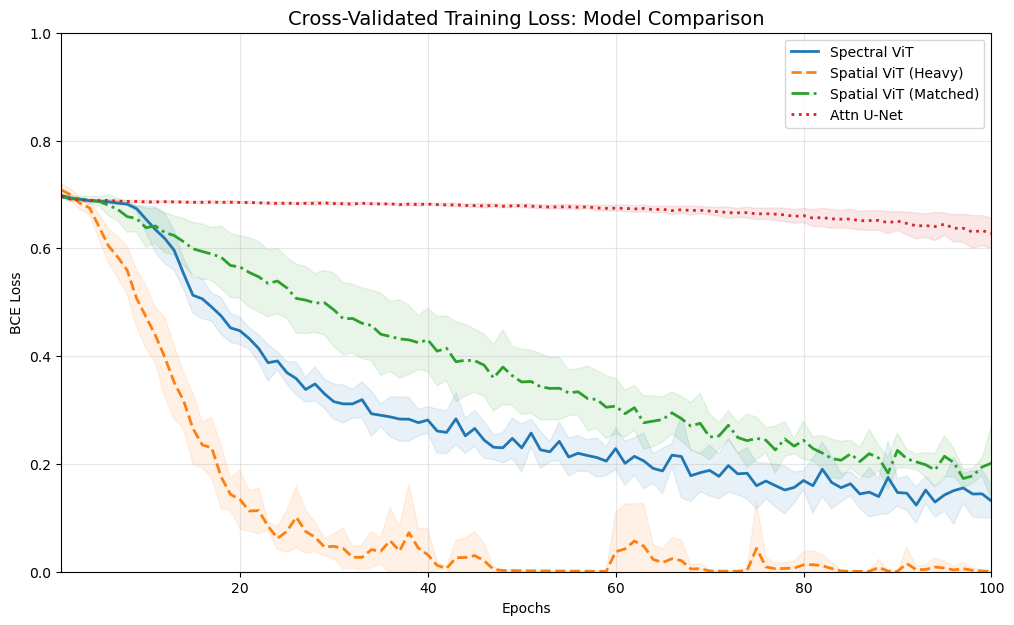

In [6]:
def plot_all_model_losses(history_dict, unet_history):
    plt.figure(figsize=(12, 7))
    
    configs = [
        ('spec_loss', 'Spectral ViT', 'tab:blue', '-'),
        ('spat_loss', 'Spatial ViT (Heavy)', 'tab:orange', '--'),
        ('spat_match_loss', 'Spatial ViT (Matched)', 'tab:green', '-.'),
        ('unet_loss', 'Attn U-Net', 'tab:red', ':')
    ]
    
    combined = {**history_dict, **unet_history}
    
    for key, label, color, style in configs:
        if key in combined and len(combined[key]) > 0:
            data = np.array(combined[key])
            mean_loss = np.mean(data, axis=0)
            std_loss = np.std(data, axis=0)
            epochs = range(1, len(mean_loss) + 1)
            
            plt.plot(epochs, mean_loss, label=label, color=color, linestyle=style, lw=2)
            plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.1)

    plt.title("Cross-Validated Training Loss: Model Comparison", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("BCE Loss")
    plt.xlim([1,100])
    plt.ylim([0,1])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_all_model_losses(all_folds_history, unet_history)

Training Swin Fold 1...
Training Swin Fold 2...
Training Swin Fold 3...
Training Swin Fold 4...
Training Swin Fold 5...
Swin AUC: 0.6397 (p vs Spectral: 0.0000)


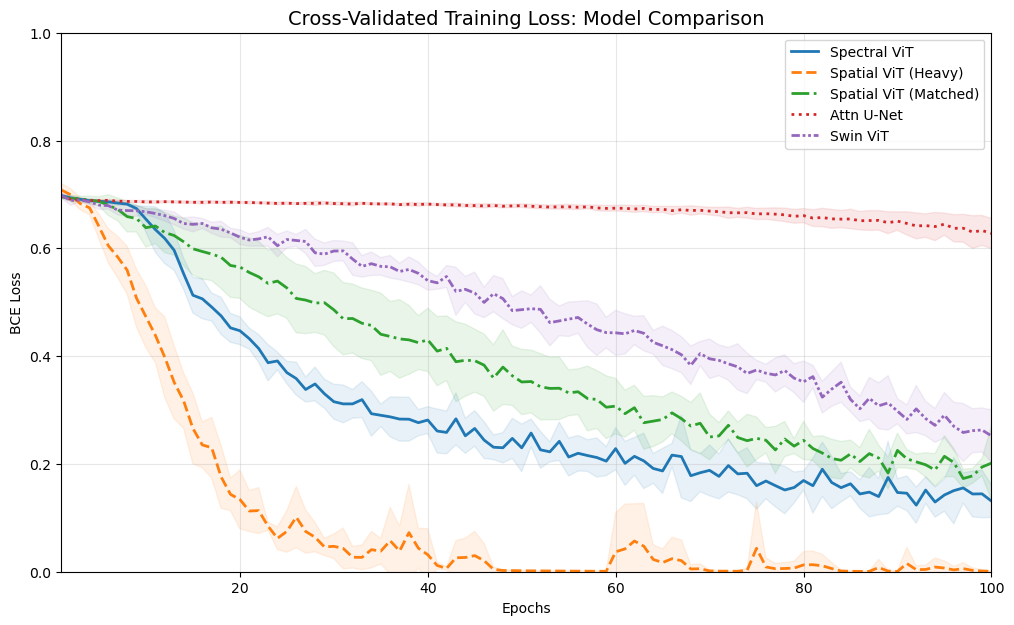

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import gc

# --- 1. Manual Swin Architecture (VRAM & Old-Torch Optimized) ---

class SwinBlock(nn.Module):
    def __init__(self, dim, input_resolution, num_heads, window_size=6, shift_size=0):
        super().__init__()
        self.dim, self.input_resolution = dim, input_resolution
        self.window_size, self.shift_size = window_size, shift_size
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.TransformerEncoderLayer(d_model=dim, nhead=num_heads, dim_feedforward=dim*2, dropout=0.1)
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape
        shortcut = x
        x = self.norm1(x).view(B, H, W, C)

        if self.shift_size > 0:
            x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))

        # Window Partitioning
        x = x.view(B, H // self.window_size, self.window_size, W // self.window_size, self.window_size, C)
        windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, self.window_size * self.window_size, C)

        # Attention
        attn_windows = self.attn(windows.transpose(0, 1)).transpose(0, 1)

        # Merge Windows
        x = attn_windows.view(B, H // self.window_size, W // self.window_size, self.window_size, self.window_size, C)
        x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, C)

        if self.shift_size > 0:
            x = torch.roll(x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))

        return shortcut + self.norm2(x.view(B, L, C))

class ManualSwin(nn.Module):
    def __init__(self, img_size=96, patch_size=8, embed_dim=32, window_size=6):
        super().__init__()
        self.patch_embed = nn.Conv2d(1, embed_dim, kernel_size=patch_size, stride=patch_size)
        res = img_size // patch_size
        self.layers = nn.ModuleList([
            SwinBlock(embed_dim, (res, res), num_heads=4, window_size=window_size, shift_size=0),
            SwinBlock(embed_dim, (res, res), num_heads=4, window_size=window_size, shift_size=window_size // 2)
        ])
        self.head = nn.Linear(embed_dim, 1)

    def forward(self, x):
        # Collapse 3D to 2D for Swin blocks
        if x.dim() == 5: x = x.mean(dim=2) 
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        for layer in self.layers:
            x = layer(x)
        x = x.mean(dim=1) 
        return self.head(x).squeeze(-1)

# --- 2. Custom Dataset for Class Balancing ---

class BalancedDataset(Dataset):
    def __init__(self, X, Y):
        self.X, self.Y = X, Y
        self.pos_idx = np.where(Y == 1)[0]
        self.neg_idx = np.where(Y == 0)[0]
        self.count = max(len(self.pos_idx), len(self.neg_idx)) * 2

    def __len__(self): return self.count

    def __getitem__(self, idx):
        i = np.random.choice(self.pos_idx) if idx % 2 == 0 else np.random.choice(self.neg_idx)
        return self.X[i], self.Y[i]

# --- 3. Training Loop ---

oof_probs_swin = []
kf = KFold(n_splits=5, shuffle=True, random_state=0)
swin_history = {'swin_loss': []}
for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    tr_vol = torch.from_numpy(X[train_idx]).unsqueeze(1).float()
    tr_y = torch.from_numpy(Y[train_idx]).float()
    ts_vol = torch.from_numpy(X[test_idx]).unsqueeze(1).float().to(device)
    ts_y = torch.from_numpy(Y[test_idx]).float().to(device)

    train_loader = DataLoader(BalancedDataset(tr_vol, tr_y), batch_size=BATCH_SIZE, shuffle=True)
    
    # img_size=96, patch_size=8 -> res=12. 12 is divisible by window_size=6.
    m_swin = ManualSwin(img_size=X.shape[-1], patch_size=8, window_size=6).to(device)
    optimizer = optim.AdamW(m_swin.parameters(), lr=1e-4,) #weight_decay=0.01)
    criterion = nn.BCEWithLogitsLoss()

    print(f"Training Swin Fold {fold+1}...")
    fold_swin_losses = []
    for epoch in range(1, EPOCHS + 1):
        m_swin.train()
        epoch_loss_swin = 0
        for b_vol, b_y in train_loader:
            b_vol, b_y = b_vol.to(device), b_y.to(device)
            optimizer.zero_grad()
            l_swin = criterion(m_swin(b_vol + torch.randn_like(b_vol)*0.01), b_y)
            l_swin.backward()
            optimizer.step()
            epoch_loss_swin += l_swin.item()
        
        # Save average epoch loss
        fold_swin_losses.append(epoch_loss_swin / len(train_loader))
    # Store fold history
    swin_history['swin_loss'].append(fold_swin_losses)

    with torch.no_grad():
        m_swin.eval()
        logits = m_swin(ts_vol)
        oof_probs_swin.append(torch.sigmoid(logits).cpu().numpy())
    
    del m_swin; gc.collect(); torch.cuda.empty_cache()

# --- 4. Final Results ---

p_swin_final = np.concatenate(oof_probs_swin)
preds_swin = (p_swin_final > 0.5).astype(int)

# P-values vs Spectral
auc_spec, auc_swin, p_auc_swin = delong_roc_test(y_final, p_spec_final, p_swin_final)
print(f"Swin AUC: {auc_swin:.4f} (p vs Spectral: {p_auc_swin:.4f})")

def plot_all_model_losses(history_dict, unet_history, swin_history):
    combined = {**history_dict, **unet_history, **swin_history}
    plt.figure(figsize=(12, 7))
    
    configs = [
        ('spec_loss', 'Spectral ViT', 'tab:blue', '-'),
        ('spat_loss', 'Spatial ViT (Heavy)', 'tab:orange', '--'),
        ('spat_match_loss', 'Spatial ViT (Matched)', 'tab:green', '-.'),
        ('unet_loss', 'Attn U-Net', 'tab:red', ':'),
        ('swin_loss', 'Swin ViT', 'tab:purple', (0, (3, 1, 1, 1, 1, 1)))
    ]
    
    
    for key, label, color, style in configs:
        if key in combined and len(combined[key]) > 0:
            data = np.array(combined[key])
            mean_loss = np.mean(data, axis=0)
            std_loss = np.std(data, axis=0)
            epochs = range(1, len(mean_loss) + 1)
            
            plt.plot(epochs, mean_loss, label=label, color=color, linestyle=style, lw=2)
            plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.1)

    plt.title("Cross-Validated Training Loss: Model Comparison", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("BCE Loss")
    plt.xlim([1,100])
    plt.ylim([0,1])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_all_model_losses(all_folds_history, unet_history, swin_history)

Training PCA+MLP Fold 1...
Training PCA+MLP Fold 2...
Training PCA+MLP Fold 3...
Training PCA+MLP Fold 4...
Training PCA+MLP Fold 5...
PCA+MLP (BCE) AUC: 0.8025 (p vs Spectral: 0.0478)
Mean Accuracy        | 79.51%             | 66.96%             | 59.89%             | 0.0000
Parameters           | 13,169             | 552,449            | 28,237             | --


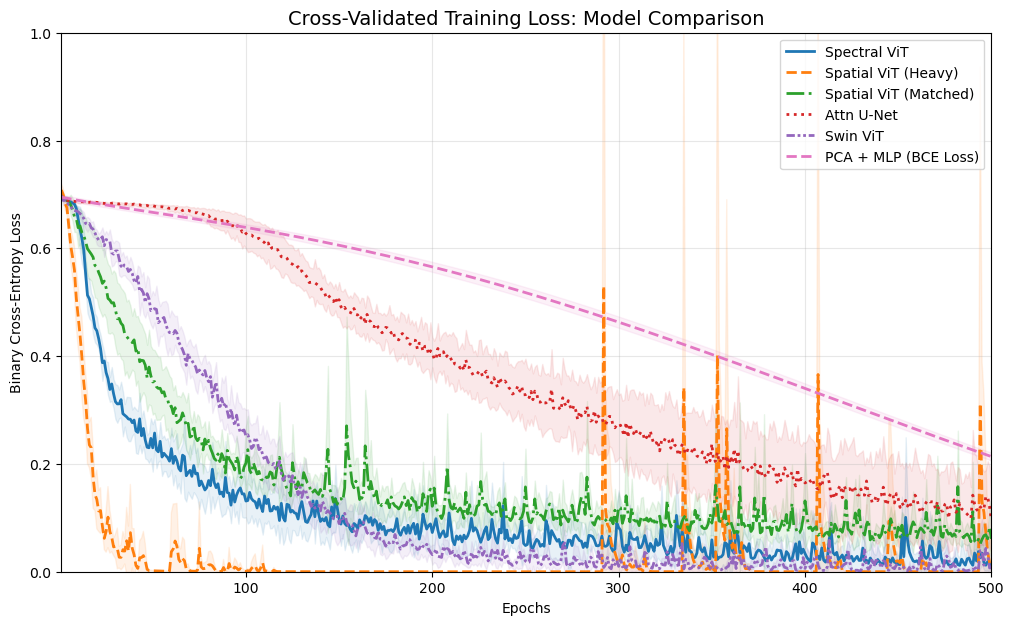

In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning
from util import seed_everything

seed_everything(0)
# --- PCA + MLP Baseline (BCE Loss) ---

oof_probs_mlp = []
mlp_history = {'mlp_bce': []}  # Renamed to reflect BCE
kf = KFold(n_splits=5, shuffle=True, random_state=0)

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"Training PCA+MLP Fold {fold+1}...")
    
    X_tr_flat = X[train_idx].reshape(len(train_idx), -1)
    X_te_flat = X[test_idx].reshape(len(test_idx), -1)
    y_tr = Y[train_idx]
    y_te = Y[test_idx]
    
    # PCA
    pca_mlp = PCA(n_components=N_COMP, whiten=True).fit(X_tr_flat)
    X_tr_pca = pca_mlp.transform(X_tr_flat)
    X_te_pca = pca_mlp.transform(X_te_flat)
    
    # MLP - Using warm_start to track BCE loss per epoch
    # solver='adam' or 'sgd' with MLPClassifier uses log-loss (BCE) for binary targets
    mlp = MLPClassifier(
        hidden_layer_sizes=(32, 32, 32, 32),
        max_iter=1,
        warm_start=True,
        random_state=0,
        learning_rate_init=1e-4,
        activation='relu',
        solver='adam',
        batch_size=len(y_tr)
    )
    
    fold_mlp_losses = []
    for epoch in range(1, EPOCHS + 1):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=ConvergenceWarning)
            mlp.fit(X_tr_pca, y_tr) # To obtain the loss at each epoch
        fold_mlp_losses.append(mlp.loss_)
    
    mlp_history['mlp_bce'].append(fold_mlp_losses)
    oof_probs_mlp.append(mlp.predict_proba(X_te_pca)[:, 1])

# Results
p_mlp_final = np.concatenate(oof_probs_mlp)
auc_spec, auc_mlp, p_auc_mlp = delong_roc_test(y_final, p_spec_final, p_mlp_final)
metrics_mlp = get_clinical_metrics(y_final, p_mlp_final)
print(f"PCA+MLP (BCE) AUC: {auc_mlp:.4f} (p vs Spectral: {p_auc_mlp:.4f})")
print(f"{'Mean Accuracy':<20} | {accuracy_score(y_final, preds_spec):<18.2%} | {accuracy_score(y_final, preds_spat):<18.2%} | {accuracy_score(y_final, preds_match):<18.2%} | {p_acc_match:.4f}")
print(f"{'Parameters':<20} | {params_spec:<18,} | {params_spat:<18,} | {params_spat_matched:<18,} | --")
def plot_all_model_losses(history_dict, unet_history, swin_history, mlp_history):
    # Combine all history dictionaries
    combined = {**history_dict, **unet_history, **swin_history, **mlp_history}
    plt.figure(figsize=(12, 7))
    
    # Config updated to look for 'mlp_bce'
    configs = [
        ('spec_loss', 'Spectral ViT', 'tab:blue', '-'),
        ('spat_loss', 'Spatial ViT (Heavy)', 'tab:orange', '--'),
        ('spat_match_loss', 'Spatial ViT (Matched)', 'tab:green', '-.'),
        ('unet_loss', 'Attn U-Net', 'tab:red', ':'),
        ('swin_loss', 'Swin ViT', 'tab:purple', (0, (3, 1, 1, 1, 1, 1))),
        ('mlp_bce', 'PCA + MLP (BCE Loss)', 'tab:pink', '--')
    ]
    
    for key, label, color, style in configs:
        if key in combined and len(combined[key]) > 0:
            data = np.array(combined[key])
            mean_loss = np.mean(data, axis=0)
            std_loss = np.std(data, axis=0)
            epochs = range(1, len(mean_loss) + 1)
            
            plt.plot(epochs, mean_loss, label=label, color=color, linestyle=style, lw=2)
            plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.1)

    plt.title("Cross-Validated Training Loss: Model Comparison", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Binary Cross-Entropy Loss")
    plt.xlim([1, EPOCHS])
    plt.ylim([0, max(1, np.max(np.mean(np.array(mlp_history['mlp_bce']), axis=0)))])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_all_model_losses(all_folds_history, unet_history, swin_history, mlp_history)